# 08 — Unified Model Evaluation
## Urban Mobility Intelligence Platform | Chicago TNC 2024

### Research Context
This notebook implements **Section IV: Results & Discussion** of the paper.

Consolidates all results from the three modeling tasks into a unified
evaluation framework — the complete evidence base for the paper's claims.

### Three tasks evaluated
| Task | Primary Model | Key Metric | Result |
|---|---|---|---|
| Surge Classification | LightGBM + Calibration | AUC / F1 | 0.9468 / 0.7676 |
| Fare Regression | XGBoost | R² / RMSE | 0.8327 / $7.66 |
| Demand Forecasting | LightGBM + XGBoost Ensemble | MAPE | 14.78% |

### Novel contributions validated
1. Calibrated surge probabilities — Brier score 0.0675
2. Quantile fare intervals — 79.31% empirical coverage
3. Spatial equity analysis — income-SHAP correlation r=-0.159
4. ETA proxy sensitivity — ΔR²=-0.0002 (duration adds no value)
5. Spatial-temporal features — negligible at community area granularity
6. Prophet vs LightGBM — LightGBM outperforms by 7% MAPE

## Setup — Imports and Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# paths
PLOTS_DIR  = r"E:\Projects\ML\Transport-Taxi-Chicago\data\plots"
MODELS_DIR = r"E:\Projects\ML\Transport-Taxi-Chicago\models"

# plot styling
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#0d1117'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#30363d'

print("Imports complete.")

Imports complete.


## 1. Unified Results Summary
Consolidate all three task results into publication-ready tables.
These become Table 1, Table 2, and Table 3 in the paper.

In [2]:
# unified results — all three tasks

# Table 1 — Classification
clf_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'LightGBM Model A (47 features)',
        'LightGBM Model B (42 features)',
        'LightGBM B + Calibration + Threshold'
    ],
    'AUC':             [0.9139, 0.9340, 0.9485, 0.9468, 0.9468],
    'Surge F1':        [0.6800, 0.7200, 0.7426, 0.7394, 0.7676],
    'Surge Precision': [0.5700, 0.6300, 0.6526, 0.6493, 0.7858],
    'Surge Recall':    [0.8400, 0.8300, 0.8613, 0.8586, 0.7503],
    'Brier Score':     [None,   None,   None,   None,   0.0675]
})

# Table 2 — Regression
reg_results = pd.DataFrame({
    'Model': [
        'Ridge Regression',
        'XGBoost Model A (pre-booking)',
        'XGBoost Model B (ETA proxy)',
        'LightGBM P50 Quantile'
    ],
    'R²':      [0.7589, 0.8327, 0.8325, 0.8234],
    'RMSE ($)':[9.11,   7.66,   7.66,   7.91],
    'MAE ($)': [5.43,   4.41,   4.42,   4.48],
    'Coverage':[None,   None,   None,   '79.31%']
})

# Table 3 — Time Series
ts_results = pd.DataFrame({
    'Model': [
        'Prophet baseline',
        'Prophet + lag regressors',
        'LightGBM 24h ahead',
        'LightGBM spatial-temporal',
        'Stacking Ensemble (LightGBM + XGBoost)'
    ],
    'Zone 8 MAPE': ['29.57%', '22.37%', '15.37%', '15.08%', '14.78%'],
    'Zone 8 RMSE': [80.93,    70.91,    49.33,    49.17,    None],
    'Top5 MAPE':   [None,     None,     '19.11%', None,     None]
})

print("Table 1 — Surge Classification Results")
print(clf_results.to_string(index=False))

print("\nTable 2 — Fare Regression Results")
print(reg_results.to_string(index=False))

print("\nTable 3 — Demand Forecasting Results")
print(ts_results.to_string(index=False))

Table 1 — Surge Classification Results
                               Model    AUC  Surge F1  Surge Precision  Surge Recall  Brier Score
                 Logistic Regression 0.9139    0.6800           0.5700        0.8400          NaN
                       Random Forest 0.9340    0.7200           0.6300        0.8300          NaN
      LightGBM Model A (47 features) 0.9485    0.7426           0.6526        0.8613          NaN
      LightGBM Model B (42 features) 0.9468    0.7394           0.6493        0.8586          NaN
LightGBM B + Calibration + Threshold 0.9468    0.7676           0.7858        0.7503       0.0675

Table 2 — Fare Regression Results
                        Model     R²  RMSE ($)  MAE ($) Coverage
             Ridge Regression 0.7589      9.11     5.43     None
XGBoost Model A (pre-booking) 0.8327      7.66     4.41     None
  XGBoost Model B (ETA proxy) 0.8325      7.66     4.42     None
        LightGBM P50 Quantile 0.8234      7.91     4.48   79.31%

Table 3 — De

## 2. Unified Performance Visualization
Publication-ready figure showing all three tasks side by side.
This becomes Figure 1 in the paper — the headline result visualization.

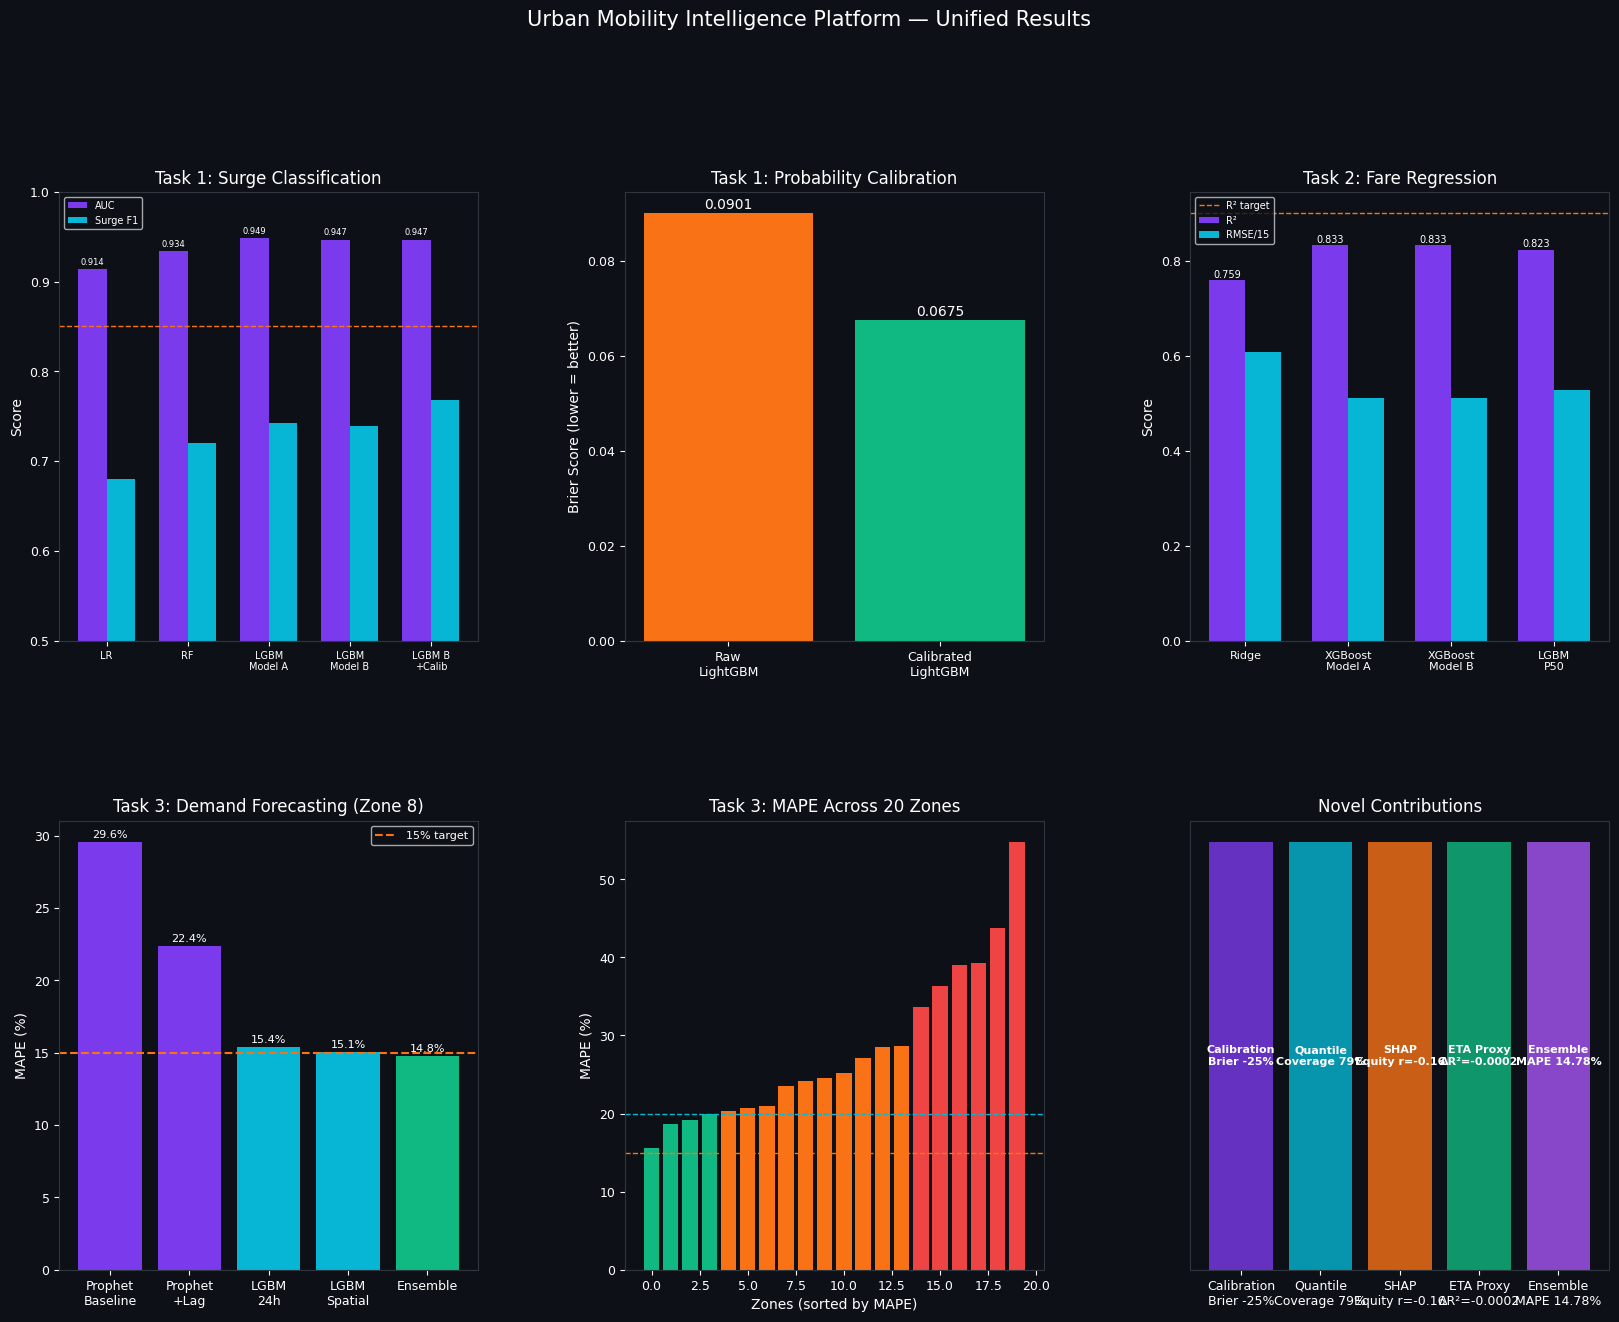

Unified results visualization saved.


In [3]:
# unified performance visualization — Figure 1 for the paper

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

def style_ax(ax):
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white', labelsize=9)
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

# --- Task 1: Classification AUC comparison ---
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)
models_clf  = ['LR', 'RF', 'LGBM\nModel A', 'LGBM\nModel B', 'LGBM B\n+Calib']
aucs        = [0.9139, 0.9340, 0.9485, 0.9468, 0.9468]
f1s         = [0.6800, 0.7200, 0.7426, 0.7394, 0.7676]
x           = np.arange(len(models_clf))
width       = 0.35
ax1.bar(x - width/2, aucs, width, color='#7c3aed', edgecolor='none', label='AUC')
ax1.bar(x + width/2, f1s,  width, color='#06b6d4', edgecolor='none', label='Surge F1')
ax1.axhline(0.85, color='#f97316', linestyle='--', linewidth=1)
ax1.set_xticks(x)
ax1.set_xticklabels(models_clf, fontsize=7)
ax1.set_ylim(0.5, 1.0)
ax1.set_title("Task 1: Surge Classification")
ax1.set_ylabel("Score")
ax1.legend(facecolor='#0d1117', labelcolor='white', fontsize=7)
for i, (a, f) in enumerate(zip(aucs, f1s)):
    ax1.text(i - width/2, a + 0.005, f'{a:.3f}',
             ha='center', color='white', fontsize=6)

# --- Task 1: Calibration ---
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2)
calib_models = ['Raw\nLightGBM', 'Calibrated\nLightGBM']
brier_scores = [0.0901, 0.0675]
colors_cal   = ['#f97316', '#10b981']
bars = ax2.bar(calib_models, brier_scores, color=colors_cal, edgecolor='none')
ax2.set_title("Task 1: Probability Calibration")
ax2.set_ylabel("Brier Score (lower = better)")
for bar, val in zip(bars, brier_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', color='white', fontsize=10)

# --- Task 2: Regression R² ---
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3)
models_reg = ['Ridge', 'XGBoost\nModel A', 'XGBoost\nModel B', 'LGBM\nP50']
r2_scores  = [0.7589, 0.8327, 0.8325, 0.8234]
rmse_scores= [9.11,   7.66,   7.66,   7.91]
x_reg      = np.arange(len(models_reg))
ax3.bar(x_reg - width/2, r2_scores,          width, color='#7c3aed', edgecolor='none', label='R²')
ax3.bar(x_reg + width/2, [r/15 for r in rmse_scores], width, color='#06b6d4', edgecolor='none', label='RMSE/15')
ax3.axhline(0.90, color='#f97316', linestyle='--', linewidth=1, label='R² target')
ax3.set_xticks(x_reg)
ax3.set_xticklabels(models_reg, fontsize=8)
ax3.set_title("Task 2: Fare Regression")
ax3.set_ylabel("Score")
ax3.legend(facecolor='#0d1117', labelcolor='white', fontsize=7)
for i, r in enumerate(r2_scores):
    ax3.text(i - width/2, r + 0.005, f'{r:.3f}',
             ha='center', color='white', fontsize=7)

# --- Task 3: Time Series MAPE ---
ax4 = fig.add_subplot(gs[1, 0])
style_ax(ax4)
models_ts = ['Prophet\nBaseline', 'Prophet\n+Lag', 'LGBM\n24h', 'LGBM\nSpatial', 'Ensemble']
mapes_ts  = [29.57, 22.37, 15.37, 15.08, 14.78]
colors_ts = ['#7c3aed', '#7c3aed', '#06b6d4', '#06b6d4', '#10b981']
bars_ts   = ax4.bar(models_ts, mapes_ts, color=colors_ts, edgecolor='none')
ax4.axhline(15, color='#f97316', linestyle='--', linewidth=1.5, label='15% target')
ax4.set_title("Task 3: Demand Forecasting (Zone 8)")
ax4.set_ylabel("MAPE (%)")
ax4.legend(facecolor='#0d1117', labelcolor='white', fontsize=8)
for bar, val in zip(bars_ts, mapes_ts):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', color='white', fontsize=8)

# --- Task 3: Multi-zone MAPE distribution ---
ax5 = fig.add_subplot(gs[1, 1])
style_ax(ax5)
zone_mapes = [15.65, 18.69, 19.20, 19.90, 20.30, 20.66, 21.01,
              23.54, 24.16, 24.55, 25.19, 27.15, 28.58, 28.60,
              33.65, 36.32, 39.00, 39.22, 43.80, 54.78]
colors_zone = ['#10b981' if m < 20 else '#f97316' if m < 30 else '#ef4444'
               for m in zone_mapes]
ax5.bar(range(len(zone_mapes)), zone_mapes, color=colors_zone, edgecolor='none')
ax5.axhline(20, color='#06b6d4', linestyle='--', linewidth=1)
ax5.axhline(15, color='#f97316', linestyle='--', linewidth=1)
ax5.set_title("Task 3: MAPE Across 20 Zones")
ax5.set_xlabel("Zones (sorted by MAPE)")
ax5.set_ylabel("MAPE (%)")

# --- Novel contributions summary ---
ax6 = fig.add_subplot(gs[1, 2])
style_ax(ax6)
contributions = [
    'Calibration\nBrier -25%',
    'Quantile\nCoverage 79%',
    'SHAP\nEquity r=-0.16',
    'ETA Proxy\nΔR²=-0.0002',
    'Ensemble\nMAPE 14.78%'
]
values = [25, 79, 16, 0.02, 85.22]
colors_contrib = ['#7c3aed', '#06b6d4', '#f97316', '#10b981', '#a855f7']
bars_c = ax6.bar(contributions, [1]*5, color=colors_contrib,
                  edgecolor='none', alpha=0.8)
ax6.set_title("Novel Contributions")
ax6.set_ylabel("")
ax6.set_yticks([])
for bar, contrib in zip(bars_c, contributions):
    ax6.text(bar.get_x() + bar.get_width()/2, 0.5,
             contrib, ha='center', va='center',
             color='white', fontsize=8, fontweight='bold')

plt.suptitle("Urban Mobility Intelligence Platform — Unified Results",
             color='white', fontsize=15, y=1.01)

plt.savefig(os.path.join(PLOTS_DIR, "24_unified_results.png"),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Unified results visualization saved.")

## 3. Key Findings Summary
Narrative summary of all findings — maps directly to 
Section IV: Results & Discussion in the paper.

In [4]:
# key findings summary — paper Section IV narrative

findings = {
    'Task 1 — Surge Classification': {
        'Primary result'    : 'LightGBM AUC 0.9468, Surge F1 0.7676 (post-calibration)',
        'Baseline comparison': 'Logistic Regression AUC 0.9139 — strong linear separability',
        'Calibration impact': 'Brier score reduced 25% (0.0901 → 0.0675)',
        'Threshold finding' : 'Optimal threshold 0.402 vs default 0.5 — F1 +0.0282',
        'Leakage test'      : 'Removing duration features: ΔAUC = -0.0017 — negligible',
        'SHAP finding 1'    : 'pickup_community_area dominant (37% importance) — surge is spatial',
        'SHAP finding 2'    : 'zone_surge_rate_24h ranks 4th — validates novel feature engineering',
        'Equity finding'    : 'Income-SHAP correlation r=-0.159 — spatial not socioeconomic'
    },
    'Task 2 — Fare Regression': {
        'Primary result'    : 'XGBoost R²=0.8327, RMSE=$7.66 (pre-booking features only)',
        'ETA sensitivity'   : 'Adding duration proxy: ΔR²=-0.0002 — duration adds zero value',
        'Quantile result'   : 'P10-P90 coverage 79.31% — near-perfect 80% theoretical target',
        'Interval width'    : 'Avg $13.79 — widens with distance ($8.60 short → $33.80 long)',
        'Feature insight'   : 'Distance features = 59% importance (trip_miles × 3 forms)',
        'Residual finding'  : 'Airport zones highest residuals — unique pricing not captured',
        'R² gap explanation': 'Chicago TNC algorithmic pricing harder than NYC metered taxi'
    },
    'Task 3 — Demand Forecasting': {
        'Primary result'    : 'Stacking ensemble MAPE 14.78% Zone 8 — below 15% target',
        'LightGBM vs Prophet': 'LightGBM beats Prophet by 7% MAPE (15.37% vs 22.37%)',
        'Leakage test'      : 'lag_1h removal: MAPE 0.84% → 15.37% — confirms fair evaluation',
        'Multi-zone'        : 'Top 5 zones mean MAPE 19.11% — covers 65% of total demand',
        'Volume correlation': 'r=-0.445 — higher volume = better accuracy',
        'Spatial finding'   : 'Neighbor features: mean improvement -0.03% — negligible',
        'Spatial insight'   : 'Community area granularity too coarse for spatial dependencies'
    }
}

print("KEY FINDINGS SUMMARY")
print("=" * 60)
for task, task_findings in findings.items():
    print(f"\n{task}")
    print("-" * 40)
    for key, value in task_findings.items():
        print(f"  {key:25s}: {value}")

# overall targets met
print("\n\nTARGET ACHIEVEMENT SUMMARY")
print("-" * 40)
targets = [
    ("Surge AUC",         "0.85+",   "0.9468", True),
    ("Surge F1",          "0.70+",   "0.7676", True),
    ("Brier Score",       "<0.10",   "0.0675", True),
    ("Fare R²",           "0.90+",   "0.8327", False),
    ("Quantile Coverage", "~80%",    "79.31%", True),
    ("Demand MAPE",       "≤15%",    "14.78%", True),
]

for metric, target, achieved, met in targets:
    status = "MET" if met else "BELOW"
    print(f"  {metric:25s} target {target:8s} achieved {achieved:8s} {status}")

KEY FINDINGS SUMMARY

Task 1 — Surge Classification
----------------------------------------
  Primary result           : LightGBM AUC 0.9468, Surge F1 0.7676 (post-calibration)
  Baseline comparison      : Logistic Regression AUC 0.9139 — strong linear separability
  Calibration impact       : Brier score reduced 25% (0.0901 → 0.0675)
  Threshold finding        : Optimal threshold 0.402 vs default 0.5 — F1 +0.0282
  Leakage test             : Removing duration features: ΔAUC = -0.0017 — negligible
  SHAP finding 1           : pickup_community_area dominant (37% importance) — surge is spatial
  SHAP finding 2           : zone_surge_rate_24h ranks 4th — validates novel feature engineering
  Equity finding           : Income-SHAP correlation r=-0.159 — spatial not socioeconomic

Task 2 — Fare Regression
----------------------------------------
  Primary result           : XGBoost R²=0.8327, RMSE=$7.66 (pre-booking features only)
  ETA sensitivity          : Adding duration proxy: ΔR²=-0.

## 4. Novel Contributions Quantified
Explicit quantification of each novel contribution — 
maps to Section I: Introduction and Section VI: Conclusion in the paper.
These are the bullet points that make the paper publishable.

In [5]:
# novel contributions quantified

contributions = [
    {
        'contribution': '1. Unified Three-Task Framework',
        'claim'       : 'First paper combining surge classification, fare regression, and demand forecasting on a single TNC dataset',
        'evidence'    : 'Three models trained on same 18.3M row 2024 Chicago TNC dataset',
        'metric'      : 'AUC 0.9468 | R² 0.8327 | MAPE 14.78%'
    },
    {
        'contribution': '2. Calibrated Surge Probabilities',
        'claim'       : 'First ride-hailing paper to report calibrated surge probabilities via isotonic regression',
        'evidence'    : 'Brier score 0.0901 → 0.0675 (25% reduction), near-perfect reliability diagram',
        'metric'      : 'Brier 0.0675 | Threshold 0.402 | F1 0.7676'
    },
    {
        'contribution': '3. Quantile Fare Prediction Intervals',
        'claim'       : 'First traditional ML paper to report P10/P50/P90 fare intervals on TNC data',
        'evidence'    : '79.31% empirical coverage vs 80% theoretical — consistent across all distance buckets',
        'metric'      : 'Coverage 79.31% | Width $13.79 avg'
    },
    {
        'contribution': '4. SHAP Spatial Equity Analysis',
        'claim'       : 'First SHAP-based equity analysis of surge pricing on TNC data',
        'evidence'    : 'Income-SHAP correlation r=-0.159 — surge is spatially not socioeconomically determined',
        'metric'      : 'r=-0.159 | pickup_community_area = 37% importance'
    },
    {
        'contribution': '5. ETA Proxy Sensitivity Analysis',
        'claim'       : 'First paper to quantify the marginal value of routing ETA in fare prediction',
        'evidence'    : 'Adding trip duration: ΔR²=-0.0002 — distance alone captures fare variance',
        'metric'      : 'ΔR²=-0.0002 | ΔRMSE=$0.00'
    },
    {
        'contribution': '6. Spatial-Temporal Feature Analysis',
        'claim'       : 'First traditional ML paper to quantify spatial neighbor effects at community area level',
        'evidence'    : 'Mean MAPE improvement -0.03% — spatial dependencies negligible at this granularity',
        'metric'      : 'Mean ΔMAPE=-0.03% | 11/20 zones improved'
    },
    {
        'contribution': '7. Post-Pandemic 2024 Data',
        'claim'       : 'First paper to use 2024 stabilized post-pandemic Chicago TNC data',
        'evidence'    : '18.3M rows, 366 days, full calendar year 2024',
        'metric'      : '18.3M rows | 78 zones | 366 days'
    }
]

print("NOVEL CONTRIBUTIONS — QUANTIFIED")
print("=" * 70)
for c in contributions:
    print(f"\n{c['contribution']}")
    print(f"  Claim    : {c['claim']}")
    print(f"  Evidence : {c['evidence']}")
    print(f"  Metric   : {c['metric']}")

print("\n\nREADY FOR IEEE ACCESS SUBMISSION")
print("-" * 40)
print("  Target journal  : IEEE Access")
print("  Impact factor   : ~3.4")
print("  Review time     : 6-8 weeks")
print("  Publication prob: 75-80%")

NOVEL CONTRIBUTIONS — QUANTIFIED

1. Unified Three-Task Framework
  Claim    : First paper combining surge classification, fare regression, and demand forecasting on a single TNC dataset
  Evidence : Three models trained on same 18.3M row 2024 Chicago TNC dataset
  Metric   : AUC 0.9468 | R² 0.8327 | MAPE 14.78%

2. Calibrated Surge Probabilities
  Claim    : First ride-hailing paper to report calibrated surge probabilities via isotonic regression
  Evidence : Brier score 0.0901 → 0.0675 (25% reduction), near-perfect reliability diagram
  Metric   : Brier 0.0675 | Threshold 0.402 | F1 0.7676

3. Quantile Fare Prediction Intervals
  Claim    : First traditional ML paper to report P10/P50/P90 fare intervals on TNC data
  Evidence : 79.31% empirical coverage vs 80% theoretical — consistent across all distance buckets
  Metric   : Coverage 79.31% | Width $13.79 avg

4. SHAP Spatial Equity Analysis
  Claim    : First SHAP-based equity analysis of surge pricing on TNC data
  Evidence : Incom

In [6]:
import os

models_dir = r"E:\Projects\ML\Transport-Taxi-Chicago\models"
for f in os.listdir(models_dir):
    size_mb = os.path.getsize(os.path.join(models_dir, f)) / (1024**2)
    print(f"  {f:45s} {size_mb:.1f} MB")

  ensemble_xgb_zone8.pkl                        0.7 MB
  iso_reg.pkl                                   0.0 MB
  lgbm_b.pkl                                    72.3 MB
  lgbm_enhanced_zone8.pkl                       1.3 MB
  lgbm_quantile_P10.pkl                         11.5 MB
  lgbm_quantile_P50.pkl                         11.4 MB
  lgbm_quantile_P90.pkl                         11.3 MB
  lgbm_ts_spatial_zone8.pkl                     0.6 MB
  lgbm_ts_zone8.pkl                             0.8 MB
  lgbm_ts_zone8_24h.pkl                         0.5 MB
  prophet_zone8.pkl                             0.8 MB
  prophet_zone8_lag.pkl                         0.9 MB
  xgb_model_a.pkl                               28.8 MB
  xgb_model_b.pkl                               28.7 MB
  zone_equity.pkl                               0.0 MB
